In [21]:
import os 
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from Utils.FilePaths import *

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from Pipeline.Decomposer.MSTLDecomposer import MSTLDecomposer
import pandas as pd
from Pipeline.Transformers.TemporalFeatureBuilder import TemporalFeatureBuilder


In [23]:
from ruhken_utils import FeatureDropTransformer

In [24]:
data_folder = PEGEL / "processed_data"
file_path = data_folder / "Pegel_hourly_cleaned-Schulau.csv"

In [25]:
df = pd.read_csv(file_path, index_col=0)
df.index = pd.to_datetime(df.index, utc=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70128 entries, 2018-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   70120 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import boxcox
import warnings
warnings.filterwarnings('ignore')

series = df['value']

# ── Key period constants ─────────────────────────────────────────────────────
H_SEMI       = 12       # S2 exact; M2 ≈ 12.42h (unavoidable with integer periods)
H_DIURNAL    = 24
H_SPRING_NEAP = 355     # ← correct: ~14.77 days × 24h (was wrongly 708)
H_ANNUAL     = 8766


In [28]:
# ── Extract Series from DataFrame FIRST ──────────────────────────────────────
series = df['value']                          # pd.Series, not DataFrame

# ── 1. Impute missing values ──────────────────────────────────────────────────
series_clean = (
    series
    .interpolate(method='time')
    .ffill()
    .bfill()
)
print(f"NaNs after cleaning: {series_clean.isna().sum()}")   # must be 0

# ── 2. Remove annual trend ────────────────────────────────────────────────────
trend_annual     = series_clean.rolling(window=H_ANNUAL, center=True, min_periods=1).median()
series_detrended = series_clean - trend_annual                # now a proper Series

print(f"Type:  {type(series_detrended)}")                    # <class 'pandas.core.series.Series'>
print(f"NaNs:  {series_detrended.isna().sum()}")             # must be 0
print(series_detrended.head())

NaNs after cleaning: 0
Type:  <class 'pandas.core.series.Series'>
NaNs:  0
timestamp
2018-01-01 00:00:00+00:00     77.0
2018-01-01 01:00:00+00:00    133.0
2018-01-01 02:00:00+00:00    165.0
2018-01-01 03:00:00+00:00    165.0
2018-01-01 04:00:00+00:00    117.0
Name: value, dtype: float64


In [16]:
# ── 2. Remove annual trend on the clean series ────────────────────────────────
trend_annual     = series_clean.rolling(window=H_ANNUAL, center=True, min_periods=1).median()
series_detrended = series_clean - trend_annual

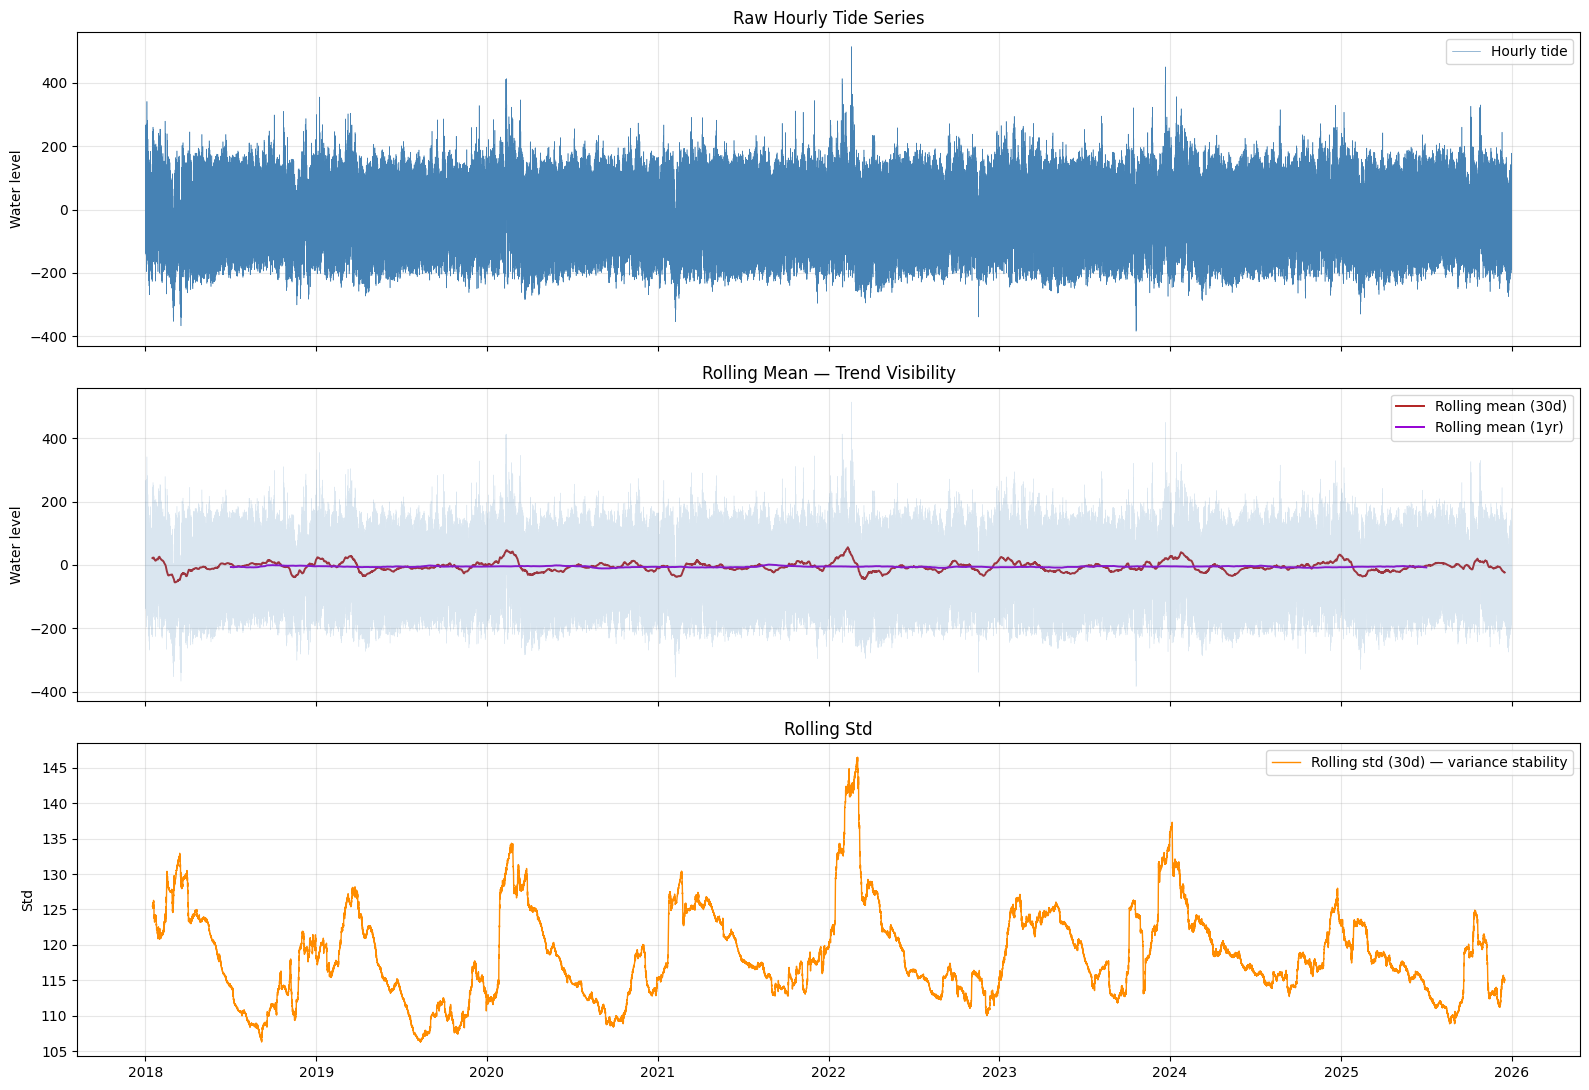

In [29]:
def plot_rolling(series: pd.Series, save: bool = False, path=None):
    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

    axes[0].plot(series, lw=0.4, color='steelblue', label='Hourly tide')
    axes[0].set_title('Raw Hourly Tide Series')
    axes[0].set_ylabel('Water level')
    axes[0].legend()

    for window, color, label in [
        (H_DIURNAL * 30,  'firebrick',   'Rolling mean (30d)'),
        (H_ANNUAL,        'darkviolet',  'Rolling mean (1yr)'),
    ]:
        roll = series.rolling(window=window, center=True).mean()
        axes[1].plot(roll, lw=1.4, color=color, label=label)
    axes[1].plot(series, lw=0.3, color='steelblue', alpha=0.2)
    axes[1].set_title('Rolling Mean — Trend Visibility')
    axes[1].set_ylabel('Water level')
    axes[1].legend()

    roll_std = series.rolling(window=H_DIURNAL * 30, center=True).std()
    axes[2].plot(roll_std, lw=1.0, color='darkorange',
                 label='Rolling std (30d) — variance stability')
    axes[2].set_title('Rolling Std')
    axes[2].set_ylabel('Std')
    axes[2].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if save:
        plt.savefig(path / 'tide_1_raw_rolling.pdf'); plt.close()
    else:
        plt.show()

plot_rolling(series_detrended)


In [31]:
def stationarity_tests(series: pd.Series, label: str = '') -> dict:
    s = series.dropna()
    adf      = adfuller(s, autolag='AIC')
    kpss_res = kpss(s, regression='c', nlags='auto')

    adf_stat  = 'STATIONARY'     if adf[1]      < 0.05 else 'NON-STATIONARY'
    kpss_stat = 'NON-STATIONARY' if kpss_res[1] < 0.05 else 'STATIONARY'

    print(f"\n{'═'*56}")
    print(f"  {label}")
    print(f"{'═'*56}")
    print(f"  ADF   stat={adf[0]:>10.4f}  p={adf[1]:.4f}  → {adf_stat}")
    print(f"  KPSS  stat={kpss_res[0]:>10.4f}  p={kpss_res[1]:.4f}  → {kpss_stat}")

    verdicts = (adf_stat, kpss_stat)
    if   verdicts == ('STATIONARY',     'STATIONARY'):
        print("  ✔  Both agree: STATIONARY")
    elif verdicts == ('NON-STATIONARY', 'NON-STATIONARY'):
        print("  ✘  Both agree: NON-STATIONARY — differencing needed")
    elif verdicts == ('STATIONARY',     'NON-STATIONARY'):
        print("  ⚠  Trend-stationary: consider detrending, not differencing")
    else:
        print("  ⚠  Difference-stationary: regular diff sufficient")

    return {'adf_p': adf[1], 'kpss_p': kpss_res[1]}

r_raw = stationarity_tests(series_detrended, 'Raw hourly series')



════════════════════════════════════════════════════════
  Raw hourly series
════════════════════════════════════════════════════════
  ADF   stat=  -19.2844  p=0.0000  → STATIONARY
  KPSS  stat=    0.0255  p=0.1000  → STATIONARY
  ✔  Both agree: STATIONARY


In [19]:
series_detrended.head()

,value
timestamp,
2018-01-01 00:00:00+00:00,77.0
2018-01-01 01:00:00+00:00,133.0
2018-01-01 02:00:00+00:00,165.0
2018-01-01 03:00:00+00:00,165.0
2018-01-01 04:00:00+00:00,117.0


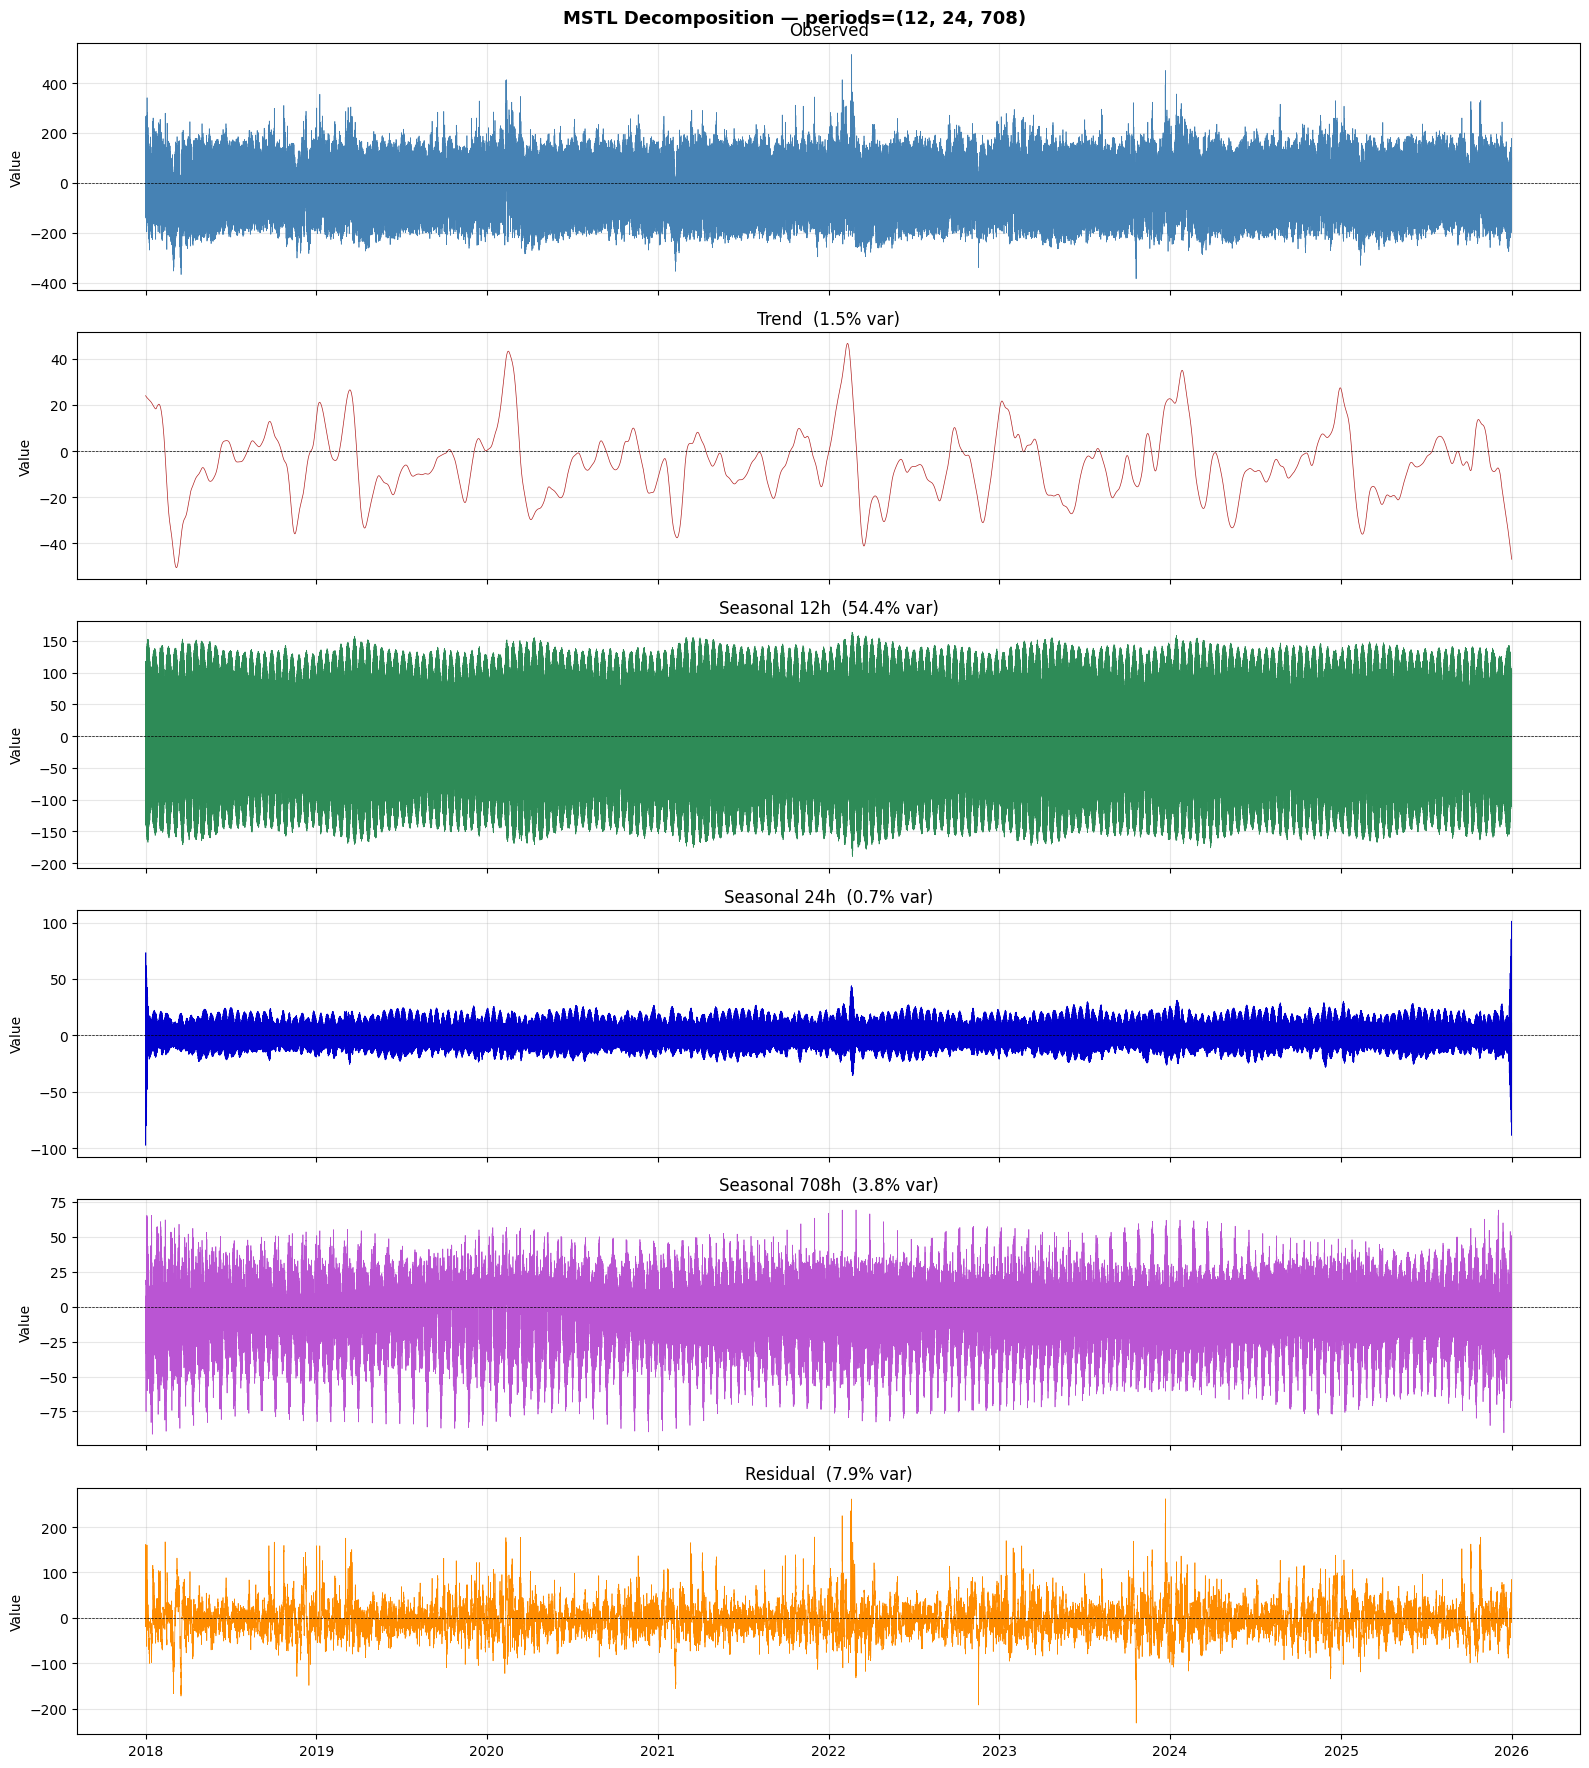


Ljung-Box on MSTL residuals:
           lb_stat  lb_pvalue
24   648072.124677        0.0
48   746317.952793        0.0
168  832564.598549        0.0
  ⚠  Autocorrelation remains — residuals not white noise


In [32]:
def plot_mstl(series: pd.Series,
              periods=(H_SEMI, H_DIURNAL, H_LUNAR),
              save: bool = False, path=None):
    """
    MSTL with 3 tidal periods:
      12h  (semi-diurnal M2/S2)
      24h  (diurnal K1/O1)
     708h  (spring/neap lunar cycle)
    Annual trend must be removed beforehand via rolling median.
    """
    mstl        = MSTL(series, periods=periods, iterate=3)
    mstl_result = mstl.fit()



    var_total = series.var()
    trend     = mstl_result.trend
    seasonal_dfs = {
        f'Seasonal {p}h': mstl_result.seasonal[f'seasonal_{p}']
        for p in periods
    }
    resid = mstl_result.resid

    components = (
        [('Observed',       series,  'steelblue'),
         (f'Trend  ({trend.var()/var_total:.1%} var)', trend, 'firebrick')]
        + [(f'{name}  ({s.var()/var_total:.1%} var)', s, c) for (name, s), c in zip(
            seasonal_dfs.items(),
            ['seagreen', 'mediumblue', 'mediumorchid'])]
        + [(f'Residual  ({resid.var()/var_total:.1%} var)', resid, 'darkorange')]
    )

    fig, axes = plt.subplots(len(components), 1,
                             figsize=(16, 3 * len(components)), sharex=True)
    for ax, (title, comp, color) in zip(axes, components):
        ax.plot(comp, lw=0.5, color=color)
        ax.set_title(title)
        ax.set_ylabel('Value')
        ax.axhline(0, color='black', lw=0.5, ls='--')
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'MSTL Decomposition — periods={periods}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    if save:
        plt.savefig(path / 'tide_2_mstl.pdf'); plt.close()
    else:
        plt.show()

    # ── Ljung-Box on residuals ────────────────────────────────────────────────
    # MSTL pads edges with NaN proportional to the largest period.
    # Never use .dropna() — interpolate boundaries instead.
    resid_clean = (
        resid
        .interpolate(method='linear', limit_direction='both')
        .fillna(0)
    )
    n = len(resid_clean)
    candidate_lags = [24, 48, 168]
    valid_lags     = [l for l in candidate_lags if l < n // 2]

    if not valid_lags:
        print(f"  ⚠  Residuals too short (n={n}) for Ljung-Box — skipping")
    else:
        lb = acorr_ljungbox(resid_clean, lags=valid_lags, return_df=True)
        print("\nLjung-Box on MSTL residuals:")
        print(lb.to_string())
        if (lb['lb_pvalue'] < 0.05).any():
            print("  ⚠  Autocorrelation remains — residuals not white noise")
        else:
            print("  ✔  Residuals ≈ white noise")

    return mstl_result


# ── Pre-detrend annual cycle, then decompose ──────────────────────────────────
mstl_result = plot_mstl(series_detrended)

In [17]:
df_trans = pegel_pipe.fit_transform(df)

In [18]:
df_trans.head()

,value_trend,value_seasonal_365,value_seasonal_30,value_lag_1,value_lag_2,value_roll_mean_2
timestamp,,,,,,
2018-01-01 00:00:00+00:00,549.080551,15.011839,-8.802256,NaN,NaN,NaN
2018-01-02 00:00:00+00:00,549.085276,11.469550,-7.150606,588.791667,NaN,NaN
2018-01-03 00:00:00+00:00,549.090002,2.130922,-50.194925,575.708333,588.791667,582.250000
2018-01-04 00:00:00+00:00,549.094727,-6.932202,-35.681957,594.000000,575.708333,584.854167
2018-01-05 00:00:00+00:00,549.099452,0.999768,0.040204,635.666667,594.000000,614.833333


In [21]:
df_trans.index

DatetimeIndex(['2018-01-01 00:00:00+00:00', '2018-01-02 00:00:00+00:00',
               '2018-01-03 00:00:00+00:00', '2018-01-04 00:00:00+00:00',
               '2018-01-05 00:00:00+00:00', '2018-01-06 00:00:00+00:00',
               '2018-01-07 00:00:00+00:00', '2018-01-08 00:00:00+00:00',
               '2018-01-09 00:00:00+00:00', '2018-01-10 00:00:00+00:00',
               ...
               '2025-12-22 00:00:00+00:00', '2025-12-23 00:00:00+00:00',
               '2025-12-24 00:00:00+00:00', '2025-12-25 00:00:00+00:00',
               '2025-12-26 00:00:00+00:00', '2025-12-27 00:00:00+00:00',
               '2025-12-28 00:00:00+00:00', '2025-12-29 00:00:00+00:00',
               '2025-12-30 00:00:00+00:00', '2025-12-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', length=2922, freq='D')

In [19]:
import seaborn as sns

<Axes: xlabel='timestamp', ylabel='value_seasonal_365'>

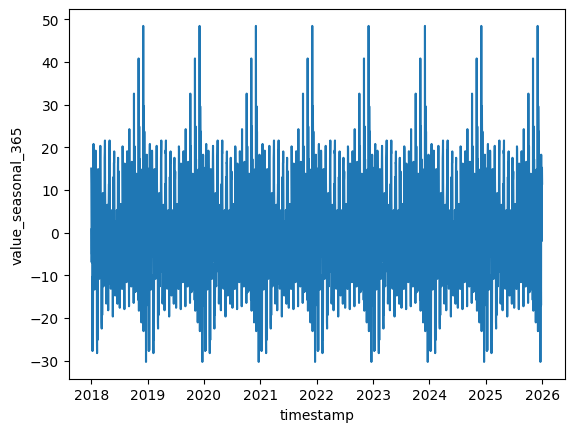

In [ ]:
sns.lineplot(data=df_trans, x=df_trans.index,  y=df_trans["value_seasonal_365"])

In [ ]:
sns.lineplot(data=df_trans, x=df_trans.index,  y=df_trans["value_seasonal_365"])

In [ ]:
from sklearn.linear_model import Ridge
import numpy as np

t = np.arange(len(series_clean))   # integer hour index

# Exact tidal constituent frequencies (cycles/hour)
constituents = {
    'M2': 1/12.4206,
    'S2': 1/12.0000,
    'N2': 1/12.6583,
    'K1': 1/23.9345,
    'O1': 1/25.8194,
    'Mf': 1/327.86,    # fortnightly
    'Mm': 1/661.31,    # monthly
}

# Build design matrix of sin/cos pairs
X = np.column_stack([
    f(2 * np.pi * freq * t)
    for freq in constituents.values()
    for f in (np.sin, np.cos)
])

model = Ridge(alpha=1e-3)
model.fit(X, series_clean.values)
fitted   = pd.Series(model.predict(X), index=series_clean.index, name='harmonic_fit')
residual = series_clean - fitted


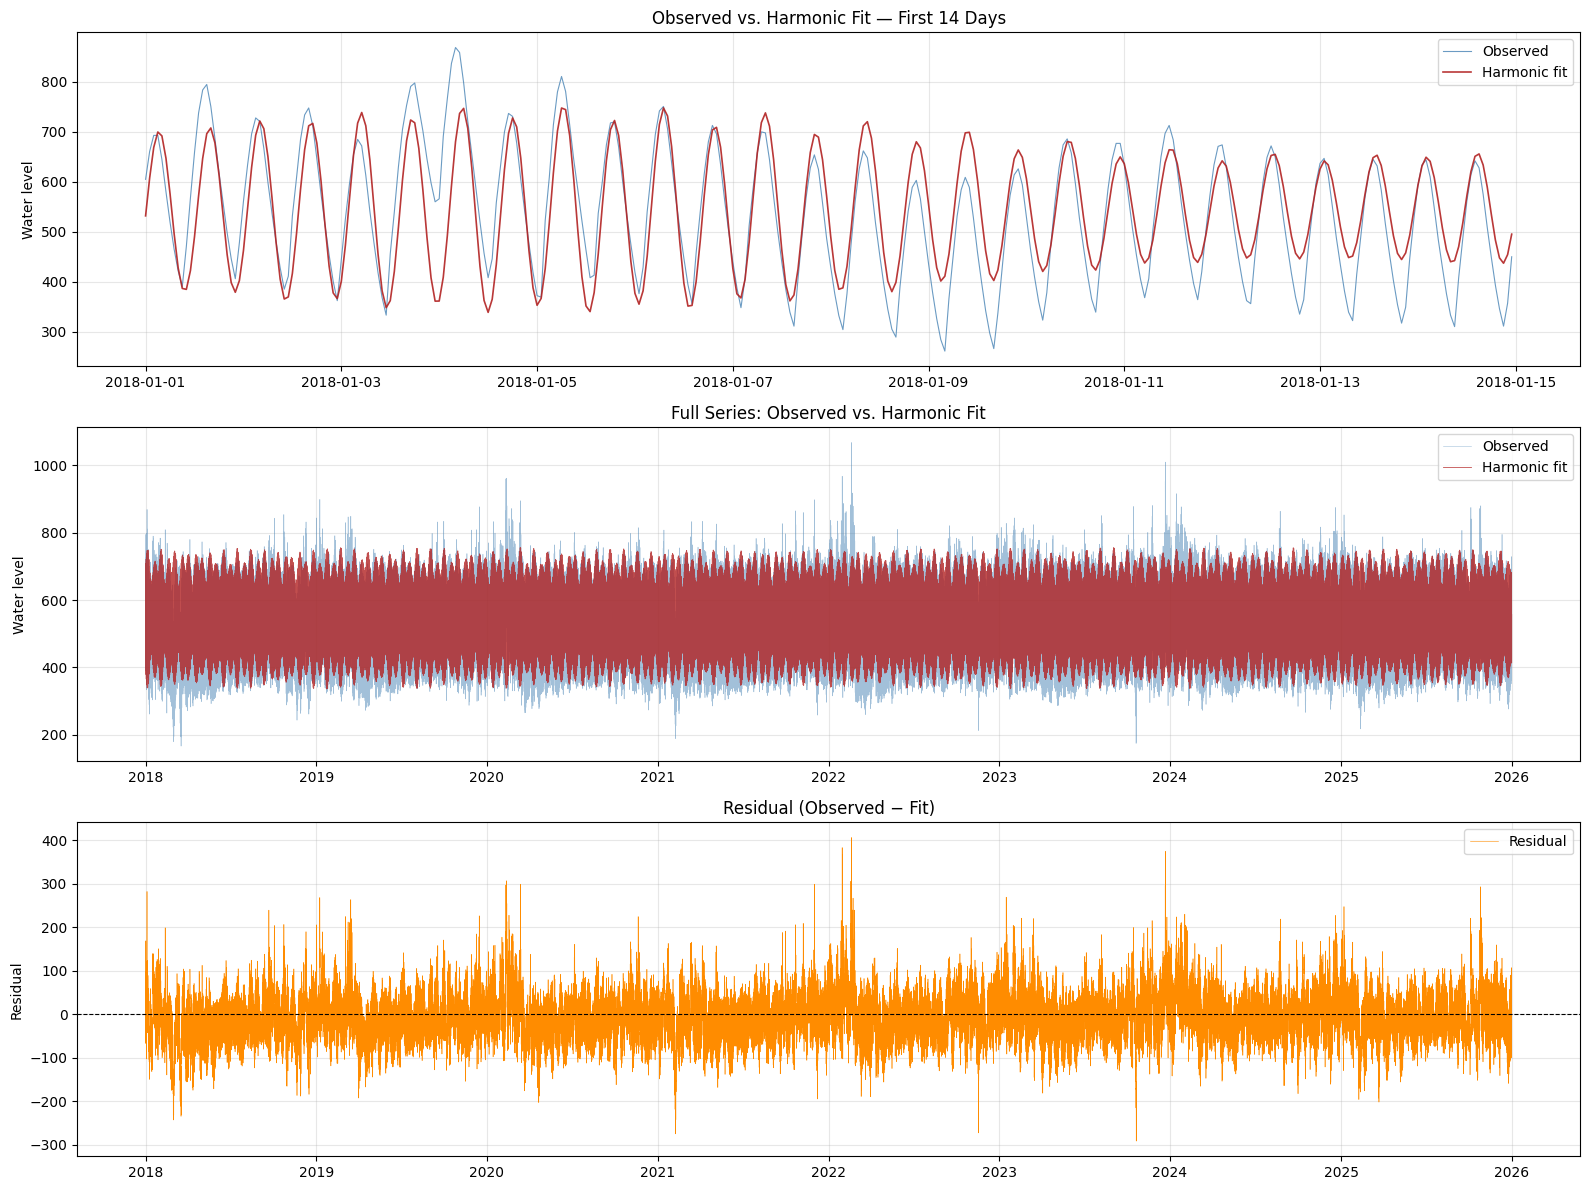

In [35]:
def plot_harmonic_fit(series: pd.Series, fitted: pd.Series,
                      residual: pd.Series, save: bool = False, path=None):
    """Plot observed vs fitted for a short window + full residual."""

    # ── Short window (2 weeks) to see tidal cycles ───────────────────────────
    window = slice(0, 24 * 14)

    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    axes[0].plot(series.iloc[window],  lw=0.8, color='steelblue', label='Observed',  alpha=0.8)
    axes[0].plot(fitted.iloc[window],  lw=1.2, color='firebrick',  label='Harmonic fit', alpha=0.9)
    axes[0].set_title('Observed vs. Harmonic Fit — First 14 Days')
    axes[0].set_ylabel('Water level')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(series,  lw=0.4, color='steelblue', label='Observed',  alpha=0.5)
    axes[1].plot(fitted,  lw=0.6, color='firebrick',  label='Harmonic fit', alpha=0.8)
    axes[1].set_title('Full Series: Observed vs. Harmonic Fit')
    axes[1].set_ylabel('Water level')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(residual, lw=0.4, color='darkorange', label='Residual')
    axes[2].axhline(0, color='black', lw=0.8, ls='--')
    axes[2].set_title('Residual (Observed − Fit)')
    axes[2].set_ylabel('Residual')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    if save:
        plt.savefig(path / 'tide_B1_fit.pdf'); plt.close()
    else:
        plt.show()

plot_harmonic_fit(series_clean, fitted, residual)


In [ ]:
df